# 第二組 Project 2：對 PTT 星宇航空相關文章進行情緒分析
- 組員：莊雅筑、胡新容、劉芊妤、許鉦偉、陳孝杰、陳柏勳、藍立衡、龍健銘

- 動機說明
    - 近期星宇動向頻傳，從引發基層熱議的「一個月年終」與 2026 年大規模機隊交付，可見其在資本支出與員工福利間的權衡；而在行銷端，透過邀請蔡依林代言並翻拍經典《布拉格廣場》MV，展現了其插旗歐洲市場的強大品牌野心。然而，面對中東地緣政治引發的燃料供應變數，星宇正逐漸面臨挑戰。

- 困難與解決方法
    - Tarflow 在 PTT 上爬蟲資料有限，因此搭配使用開源[ptt-crawler](https://www.npmjs.com/package/@waynechang65/ptt-crawler)爬蟲，抓取資料。

- 本分析將藉由彙整 PTT（如 Stock、Aviation 板）之社群輿情，拆解大眾對於星宇「精品行銷」與「經營壓力」的真實看法，評估其在高度不確定的環境下，如何維持品牌溢價並平衡利害關係人期待。
------------------------------------------------------------------------------
- 專案進度**從第六週課程開始** 為「文辭和文件分析」，目的為透過TF-IDF, N-gram等方法找出文章以及字詞間的關聯。
以PTT 星宇航空相關文章做為分析資料。

## 大綱
1. 套件說明 
2. 資料前處理
    - 2.1 基本資料介紹
    - 2.2 資料清理
    - 2.3 文章斷詞與整理
3. 找出重要詞彙 - 以TFIDF為例
    - 3.1 計算TF-IDF示範（公式）
    - 3.2 應用於資料集（套件） 
    - 3.3 檢視結果
4.  透過結巴斷詞與N-gram幫助建立斷詞字典
    - 4.1 Bigram
    - 4.2 Trigram
    - 4.3 更新斷詞字典
    - 4.4 Bigram視覺化
5.  Pairwise correlation
    - 5.1 找出相關性高的詞彙
    - 5.2 畫出關係圖
6. 計算文章相似度
7. 補充：建立Ngram預測模型


## 1. 套件說明

下面列出在本次實作過程中我們所使用到的相關套件，在這個Jupyter Notebook當中我們將會簡單的展示這些套件的使用方式，關於各個套件的進階使用請同學參照其官網的說明。
- pandas: 一個資料分析的函式庫，提供了DataFrame等資料格式，與資料處理的函數。
- numpy: 為科學運算所提供的套件。提供許多數學公式的實作以及高效率的陣列、矩陣運算。
- NLTK: 全名為Natural Language Tool Kit，自然語言處理工具。
- jieba: 中文斷詞套件。
- re: 正規表達式套件。
- math: 數學運算工具。
- collections: 提供額外的數據類型。
- matplotlib: 繪圖工具。
- networkx: 網絡圖建構、繪製工具。
- CountVectorizer, TfidfTransformer: sklearn中計算詞頻與tf-idf的套件。
- numpy.linalg: 矩陣與向量運算套件。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import re
import jieba
import jieba.analyse
import math
from nltk import ngrams, FreqDist
from collections import Counter, namedtuple

import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity


C:\Users\user\anaconda3\envs\SMA_G2_PRJ1\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# 設定圖的中文字體 (無法顯示的話可以試試‘Microsoft JhengHei’字體)
# 也可參考：https://pyecontech.com/2020/03/27/python_matplotlib_chinese/
#plt.rcParams['font.sans-serif'] = ['Arial Unicode Ms'] #使圖中中文能正常顯示
#plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

## 2. 資料前處理

### 2.1 資料介紹
資料來源：
- 使用開源[ptt-crawler](https://www.npmjs.com/package/@waynechang65/ptt-crawler)爬蟲，抓取PTT 文章。
- 版：「Aviation」、「Stock」
- 標題關鍵字：「星宇」
- 時間: 2025-12-01 ~ 2026-03-18

In [3]:
# 讀取星宇航空的 PTT 文章資料
df = pd.read_csv("raw_data/starlux_dataset.csv")
df.head(3)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到


### 2.2 資料初步清理
- 去除特殊字元與標點符號，只留下中文字
- \u4e00-\u9fff 為Unicode中文漢字字符的範圍

In [4]:
clear_df = df.copy()

# 去除一些不需要的欄位
clear_df = clear_df.drop(['artPoster', 'board', 'rowType'], axis=1)
# 只留下中文字
clear_df['sentence'] = clear_df['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

clear_df.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到


### 2.3 文章斷詞與整理

In [5]:
# 設定繁體中文詞庫 
jieba.set_dictionary('./dict/dict.txt')

# 新增stopwords 
with open('./dict/stopwords.txt', encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [6]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [7]:
data = clear_df.copy()

# 斷詞、去除停用字並將word欄位展開
data['word'] = data.sentence.apply(getToken).explode('word')

data.head(3)

Building prefix dict from C:\Users\user\Desktop\SMA\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\user\AppData\Local\Temp\jieba.ud5f8d3fb4900672350eb84ec3a4e1524.cache
Loading model cost 0.439 seconds.
Prefix dict has been built successfully.


,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,新加坡
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,台灣


## 3. 找出重要詞彙 - 以TFIDF為例

TF-IDF 是一種統計方法，可用來評估單詞對於文件的集合的重要程度  
- **TF** (Term Frequency)：某一個詞彙在某一個文件中所出現的頻率  
    - TF = 詞彙在該文件中出現次數 / 該文件中詞彙總數  
- **IDF** (Inverse Document Frequent)：為文件數除以某特定詞彙有被多少文件所提及的數量取log  
    - IDF = log( 總文件數量 / 包含該詞彙的文件數量 ) 

### 3.1 計算TF-IDF示範（公式）

#### 建立示範文件

In [8]:
# 一些短句子示範
doc1 = """中山大學位於高雄柴山地區，附近野生獼猴猖獗，常搶學生食物，甚至抓傷學生，學校推出「與獼猴共存」政策，學生食物若被獼猴搶走，每次可向學校申請上限一百元補償金。
中山大學校園內近日張貼公告，宣導學生食物不外露，勿手拿會吸引獼猴搶奪的食物、提袋、塑膠袋或紙袋等，「如遇到獼猴掠食，先確保自身安全，放棄食物，避免在爭奪過程中受傷」。
校方於二至七月試辦補償措施，只要學生在柴山校區的商店購買食物被獼猴搶食，可到校內店家再次購買餐食，每人每餐補償上限為一百元，不過截至昨天為止，尚未有同學提出申請。"""

doc2 = """國立中山大學為住宿學生提供貼心服務，引進現煮拉麵熱食販賣機，並開放24小時使用「自煮空間」，滿足所有住宿學生的味蕾。
宿舍區同步升級多項軟硬體設施，包含逐步整修換新、定期辦理主題講座、職涯發展分享會、節慶交流活動、增設更多公共空間，並推動「衣服再利用」永續計畫，期能兼顧各種需求，提升住宿品質。
中山大學為方便住宿學生就近覓食，特地引進現煮拉麵熱食販賣機，於今年1月初進駐校園翠亨C棟、雨樹L棟及武嶺武二村聽濤堂前三個宿舍區點，鄰近自習室公共空間，提供大家更多選擇。"""

doc3 = """為了促進第二、第三外語與跨文化學習交流，國立中山大學外文系首辦「在中山說第二外語」語言交換活動，打造練習外語聽說環境，使學生在中山便有機會認識世界、擴展視野，
在全球化下能海納百川，欣賞多國多語言的多元文化。「在中山說第二外語」語言交換活動獲文學院與國際事務處支持推廣，學生參與踴躍，2場次參加人數達70人次，
其中多達半數為非外文系學生，參與外籍生亦來自歐、亞、美洲等不同國家，活動中以德文、法文、西班牙文、日文及韓文使用者為大宗。"""

sample_df = pd.DataFrame({'doc':[1,2,3], 'text': [doc1, doc2, doc3]})

sample_df

,doc,text
0,1,中山大學位於高雄柴山地區，附近野生獼猴猖獗，常搶學生食物，甚至抓傷學生，學校推出「與獼猴共存...
1,2,國立中山大學為住宿學生提供貼心服務，引進現煮拉麵熱食販賣機，並開放24小時使用「自煮空間」，...
2,3,為了促進第二、第三外語與跨文化學習交流，國立中山大學外文系首辦「在中山說第二外語」語言交換活...


資料清理

In [9]:
sample_df['text'] = sample_df['text'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))
sample_df = sample_df.assign(word = sample_df['text'].apply(getToken)).explode('word')

sample_df.head()

,doc,text,word
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,中山
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,大學
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,位於
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,高雄
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,柴山


#### 計算各文章的總詞彙數

In [10]:
total_words = sample_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})
total_words.head()

,doc,total
0,1,86
1,2,87
2,3,75


#### 計算各文章的各個詞彙數

In [11]:
word_count = sample_df.groupby(['doc', 'word'], as_index = False).size()

word_count.rename(columns={'size': 'count'}, inplace=True)
word_count.sort_values('count', ascending=False).head()

,doc,word,count
46,1,獼猴,6
60,1,食物,6
19,1,學生,5
135,3,中山,4
69,2,住宿,4


合併需要的資料欄位
- 合併 **每個詞彙在每篇文章中出現的次數** 與 **每篇文章的詞數**

In [12]:
sample_merged = word_count.merge(total_words, on = 'doc', how = 'left')
sample_merged.head(3)

,doc,word,count,total
0,1,一百元,2,86
1,1,七月,1,86
2,1,上限,2,86


#### 計算 TF值

In [13]:
# 計算tf = 詞彙在該文件中出現次數 / 該文件中詞彙總數 
sample_tf_idf = sample_merged.assign(tf = sample_merged["count"] / sample_merged["total"])
sample_tf_idf.head()

,doc,word,count,total,tf
0,1,一百元,2,86,0.023256
1,1,七月,1,86,0.011628
2,1,上限,2,86,0.023256
3,1,中山,2,86,0.023256
4,1,二至,1,86,0.011628


#### 計算 IDF值

In [14]:
# 計算每個詞彙出現在幾篇文章中
idf_df = sample_merged.groupby(['word'], as_index = False).size()

# 合併到之前的df中
sample_tf_idf = sample_tf_idf.merge(idf_df, on = 'word', how = 'left')

sample_tf_idf.head()

,doc,word,count,total,tf,size
0,1,一百元,2,86,0.023256,1
1,1,七月,1,86,0.011628,1
2,1,上限,2,86,0.023256,1
3,1,中山,2,86,0.023256,3
4,1,二至,1,86,0.011628,1


In [15]:
# 計算idf = log( 總文件數量 / 包含該詞彙的文件數量 ) 
sample_tf_idf = sample_tf_idf.assign(idf = sample_tf_idf["size"].apply(lambda size: math.log( len(total_words) / size, 10 ))).drop(["size"], axis=1)

sample_tf_idf.head()

,doc,word,count,total,tf,idf
0,1,一百元,2,86,0.023256,0.477121
1,1,七月,1,86,0.011628,0.477121
2,1,上限,2,86,0.023256,0.477121
3,1,中山,2,86,0.023256,0.000000
4,1,二至,1,86,0.011628,0.477121


#### 計算 TFIDF值

In [16]:
# 計算tf*idf
sample_tf_idf = sample_tf_idf.assign(tf_idf = sample_tf_idf["tf"] * sample_tf_idf["idf"])

sample_tf_idf.sort_values('tf_idf', ascending = False).head(10)

,doc,word,count,total,tf,idf,tf_idf
46,1,獼猴,6,86,0.069767,0.477121,0.033288
60,1,食物,6,86,0.069767,0.477121,0.033288
154,3,外語,4,75,0.053333,0.477121,0.025446
69,2,住宿,4,87,0.045977,0.477121,0.021937
178,3,第二,3,75,0.040000,0.477121,0.019085
185,3,語言,3,75,0.040000,0.477121,0.019085
110,2,空間,3,87,0.034483,0.477121,0.016452
152,3,外文系,2,75,0.026667,0.477121,0.012723
137,3,交換,2,75,0.026667,0.477121,0.012723
147,3,參與,2,75,0.026667,0.477121,0.012723


In [17]:
# 選出每個文件，tf-idf值最大的前三個詞
group = sample_tf_idf.groupby("doc").apply(lambda x : x.nlargest(3, "tf_idf"))
group

C:\Users\user\AppData\Local\Temp\ipykernel_34880\1751358733.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group = sample_tf_idf.groupby("doc").apply(lambda x : x.nlargest(3, "tf_idf"))


doc word  count  total        tf       idf    tf_idf
doc                                                          
1   46     1   獼猴      6     86  0.069767  0.477121  0.033288
    60     1   食物      6     86  0.069767  0.477121  0.033288
    0      1  一百元      2     86  0.023256  0.477121  0.011096
2   69     2   住宿      4     87  0.045977  0.477121  0.021937
    110    2   空間      3     87  0.034483  0.477121  0.016452
    71     2   公共      2     87  0.022989  0.477121  0.010968
3   154    3   外語      4     75  0.053333  0.477121  0.025446
    178    3   第二      3     75  0.040000  0.477121  0.019085
    185    3   語言      3     75  0.040000  0.477121  0.019085

### 3.2 應用於資料集（套件）

除了直接用公式計算，也可以使用sklearn中計算詞頻與tf-idf的套件。

DTM 介紹
- Document term matrix (DTM)，是一種用於自然語言處理的數學矩陣，描述了在一組文件中各個詞彙出現的頻率。   
- DTM 中的每一行代表一個文件(Document)，每一列代表一個詞彙(Term)，每一格的值表示該詞彙在該文件中的出現次數。

舉例來說，若有三個文件其內容如下：
- 文件1：「今天天氣很好」
- 文件2：「今天是星期五」
- 文件3：「昨天是星期四而且天氣很好」

而這些文件斷完詞後的結果可能為：
- 文件1：「今天／天氣／很／好」
- 文件2：「今天／是／星期五」
- 文件3：「昨天／是／星期四／而且／天氣／很／好」
 

In [18]:
starlux_df = data.copy()
starlux_df.head(3)    

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,新加坡
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,台灣


In [19]:
# 保留需要的欄位
starlux_df = starlux_df.loc[:,["system_id", "sentence"]]

# 改成使用空格連接斷完的詞
starlux_df['word'] = starlux_df.sentence.apply(getToken).map(' '.join)

starlux_df.head()

,system_id,sentence,word
0,0,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡 台灣 星宇星 加坡 長榮 票價 星宇 便宜 明白 那麼多 選星宇 累計 里程 ...
1,1,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,這有 糾結 沒高卡 哩程 需求 便宜
2,2,星宇你應該是看到只能托運一件的我最近也有注意到,星宇 看到 托運 一件 最近 注意到
3,3,金城武都選長榮你參考,金城武 長榮 參考
4,4,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到,哩程 卡客 便宜 便宜 低價票 設定 促銷 票給 看到


In [20]:
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(starlux_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一三四六,一下,一二嘛,一人,一代,一件,一份,一位,一併,一個點,...,鼎立,鼓勵,鼓吹,鼓舞,鼻子,鼻酸,齊發,龍眼,龍頭,龐大
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4079,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
transformer = TfidfTransformer()  
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)  

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())

TFIDF_df

,一三四六,一下,一二嘛,一人,一代,一件,一份,一位,一併,一個點,...,鼎立,鼓勵,鼓吹,鼓舞,鼻子,鼻酸,齊發,龍眼,龍頭,龐大
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.508782,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4079,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4081,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.3 檢視結果   
根據tfidf值來挑出重要詞彙的方法有許多種，以下舉兩個方法當範例：
- 取每一個字詞在所有文件裡的TF-IDF平均值
- 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

#### 方法1： 取每一個字詞在所有文件裡的TF-IDF平均值

In [22]:
starlux_tfidf = TFIDF_df.mean().to_frame().reset_index() ## !!
starlux_tfidf.columns = ["word", "avg"]

starlux_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
4771,星宇,0.021940
1294,公司,0.016643
3412,年終,0.016298
2122,員工,0.016100
9921,飛機,0.012984
9434,長榮,0.012467
7672,華航,0.012389
7571,航空,0.011010
1936,台中,0.010086
7246,罷工,0.009826


#### 方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [23]:
#toptens = starlux_tfidf.copy()
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index+1)

toptens

,doc_id,一三四六,一下,一二嘛,一人,一代,一件,一份,一位,一併,...,鼎立,鼓勵,鼓吹,鼓舞,鼻子,鼻酸,齊發,龍眼,龍頭,龐大
0,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.508782,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,4079,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4079,4080,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,4081,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4081,4082,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
toptens = toptens.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens

,doc_id,word,tfidf
0,1,一三四六,0.0
1,2,一三四六,0.0
2,3,一三四六,0.0
3,4,一三四六,0.0
4,5,一三四六,0.0
...,...,...,...
41618014,4079,龐大,0.0
41618015,4080,龐大,0.0
41618016,4081,龐大,0.0
41618017,4082,龐大,0.0


nlargest() 會回傳指定列中最大的前x個值所對應的資料

In [25]:
#把 tfidf 這個欄位裡面的所有東西，都轉換成「數字 (Numeric) 型態」。
toptens['tfidf'] = pd.to_numeric(toptens['tfidf'], errors='coerce')

#過濾掉0分的詞(字詞沒有出現的)，只保留 tfidf 分數大於 0 的資料
toptens = toptens[toptens['tfidf'] > 0]
(
    # 從每篇文章挑選出tf-idf最大的前十個詞
    toptens.groupby("doc_id").apply(lambda x : x.nlargest(10, "tfidf"), include_groups=False).reset_index(drop=True)
   
    # 計算每個詞被選中的次數
    .groupby(['word'],as_index=False).size()

).sort_values('size', ascending=False).head(10) # 排序看前十名

,word,size
3683,星宇,313
2627,年終,204
1635,員工,203
1010,公司,202
7547,飛機,158
5861,華航,146
7188,長榮,145
5792,航空,135
1497,台中,118
5530,罷工,101


## 4. 透過結巴斷詞與N-gram幫助建立斷詞字典
N-gram 指文本中連續出現的n個語詞。   
透過N-gram我們可以找出有哪些詞彙較常一起出現，檢查是否需要加入自定義字典中。   

N-gram範例：

In [26]:
token = jieba.lcut("中山資管全國第一")
token

['中山', '資管', '全國', '第一']

In [27]:
# 利用nltk的ngrams()
# Bigram
bigram  = ngrams(token, 2)
list(bigram)

[('中山', '資管'), ('資管', '全國'), ('全國', '第一')]

In [28]:
# Trigram
trigram  = ngrams(token, 3)
list(trigram)

[('中山', '資管', '全國'), ('資管', '全國', '第一')]

### 4.1 Bigram

In [29]:
# 設定 ngram 斷詞 function
def ngram_getToken(row, n):
    # 進行斷詞
    seg_list = jieba.lcut(row)

    # 篩選掉停用字與字元數小於1的詞彙
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1]

    # ngram斷詞
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]
    
    return seg_list

In [30]:
starlux_bigram = data.copy()

starlux_bigram["word"] = starlux_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
starlux_bigram = starlux_bigram.explode('word')

starlux_bigram.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,新加坡 台灣
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,台灣 星宇星


#### 統計最常出現的bigram組合

In [31]:
# 計算每個組合出現的次數
starlux_bigram_count = starlux_bigram['word'].value_counts().reset_index()

starlux_bigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,星宇 航空,206
1,航空 公司,83
2,年終 獎金,68
3,長榮 華航,36
4,華航 長榮,30
5,星宇 員工,27
6,精品 航空,24
7,員工 年終,24
8,新創 公司,18
9,原文 連結,18


從上面的 bigram 和 trigram 的結果中，我們發現"星宇 航空"、"航空 公司"等詞可以組合在一起，所以我們增加自定義字典來幫助斷詞能更準確。  
我們將詞彙整理好存在 dict 文件夾中的 user_dict 中。

In [32]:
# 載入自定義辭典：一個詞一行，每行分詞語、詞頻(可省)、詞性(可省)
jieba.load_userdict("./dict/user_dict.txt")

In [33]:
# 剛才的斷詞結果沒有使用新增的辭典，因此我們重新進行斷詞
data2 = data.copy()
data2['word'] = data2.sentence.apply(getToken)
data2 = data2.explode('word')

data2.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,新加坡
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,台灣


### 4.4 Bigram視覺化

更新斷詞字典後重新進行bigram斷詞

In [34]:
bigramfdist = data.copy()

bigramfdist["word"] = bigramfdist['sentence'].apply(lambda row: ngram_getToken(row, 2))
bigramfdist = bigramfdist.explode('word')

bigramfdist.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,新加坡 台灣
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,台灣 星宇星


In [35]:
bigramfdist['word'] = bigramfdist['word'].astype(str)

# 使用FreqDist 取得 bigram 斷詞 與 bigram出現頻率
bigramfdist = FreqDist(bigramfdist['word'].apply(lambda x: tuple(x.split(' '))))
bigramfdist.most_common(5)


[(('nan',), 437),
 (('星宇', '航空'), 206),
 (('航空', '公司'), 83),
 (('年終', '獎金'), 68),
 (('長榮', '華航'), 36)]

除了利用N-gram來幫助建立斷詞字典，N-gram也能幫助我們發現詞與詞之間的連貫關係。

接下來針對重新斷詞後的bigram出現頻率最高的前50對進行視覺化，觀察文章的關鍵詞

In [36]:
# 建立bigram和count的dictionary
# 這裡取最多的前50項
d = {k:v for k,v in bigramfdist.most_common(50)}

In [37]:
import networkx as nx

# Create network plot 
G = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d][0].items():
    # ==========================================
    # 關鍵：檢查 k 裡面是不是真的有兩個詞！
    # 只有長度大於等於 2 的組合，才允許建立連線
    # ==========================================
    if len(k) >= 2:
        G.add_edge(k[0], k[1], weight=v) # nodes：詞彙，weight：組合出現頻率
    else:
        # 如果只有一個詞，我們就印出來看看是誰在搗亂，然後跳過它
        print(f"發現落單的詞彙，已跳過：{k}")
        
# 取得調整edge權重
weights = [w[2]['weight']*0.05 for w in G.edges(data=True)]

print(f"網路圖連線成功！目前圖中有 {G.number_of_nodes()} 個節點，與 {G.number_of_edges()} 條連線。")

發現落單的詞彙，已跳過：('nan',)
網路圖連線成功！目前圖中有 50 個節點，與 47 條連線。


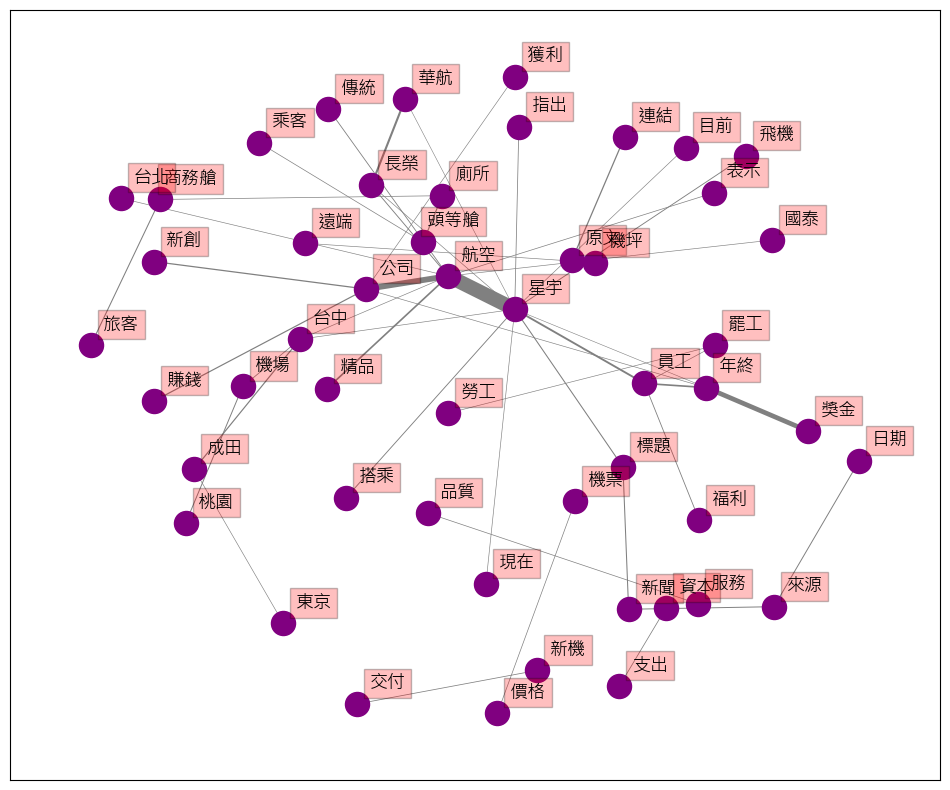

In [38]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=1.5)

# networks
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)
    
plt.show()

## 5. Pairwise correlation

計算兩個詞彙間的相關性 Pearson correlation

In [39]:
data_cor = data.copy()

# 需要改成使用空格連接斷好的詞
data_cor['word'] = data_cor.sentence.apply(getToken).map(' '.join)
data_cor.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡 台灣 星宇星 加坡 長榮 票價 星宇 便宜 明白 那麼多 選星宇 累計 里程 ...
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,這有 糾結 沒高卡 哩程 需求 便宜
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,星宇 看到 托運 一件 最近 注意到


In [40]:
# Bag of Word
# 篩選至少出現在5篇文章以上且詞頻前500的詞彙
vectorizer = CountVectorizer(min_df = 5, max_features = 500)
X = vectorizer.fit_transform(data_cor["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一下,一堆,一天,一年,一架,一次,一直,一間,一點,三家,...,飛航,飛行,餐點,首架,首爾,首航,香港,體驗,高雄,鳳凰城
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4079,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
# 計算詞之間的相關係數
corr_matrix = np.corrcoef(DTM_df.T)

# 轉成dataframe
Cor_df = pd.DataFrame(corr_matrix, index = DTM_df.columns, columns = DTM_df.columns)

Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace = True, drop = True)

Cor_df

,word1,一下,一堆,一天,一年,一架,一次,一直,一間,一點,...,飛航,飛行,餐點,首架,首爾,首航,香港,體驗,高雄,鳳凰城
0,一下,1.000000,0.030614,0.083635,-0.009305,0.053741,0.014719,0.042796,0.052901,0.070924,...,0.045156,0.073443,0.067741,-0.004376,0.060647,-0.006319,0.071885,0.049048,0.007563,-0.003289
1,一堆,0.030614,1.000000,-0.008217,-0.012643,-0.008217,0.026778,0.016229,-0.009396,-0.006011,...,-0.006360,0.016848,0.016970,-0.005946,-0.009767,-0.008586,-0.008711,-0.008405,0.016771,-0.004469
2,一天,0.083635,-0.008217,1.000000,-0.004630,0.059679,-0.004142,0.022807,0.059276,0.022874,...,0.049925,0.030237,0.058622,-0.002177,0.043840,-0.003144,-0.003190,0.054835,0.039077,-0.001636
3,一年,-0.009305,-0.012643,-0.004630,1.000000,-0.004630,0.075800,0.073626,-0.005294,0.039940,...,-0.003584,0.109536,0.204265,0.017823,-0.005503,0.022520,0.057137,0.192230,0.015131,0.004419
4,一架,0.053741,-0.008217,0.059679,-0.004630,1.000000,0.044180,-0.006935,-0.003441,0.022874,...,-0.002329,0.064070,0.027998,-0.002177,-0.003577,-0.003144,0.106267,-0.003078,0.039077,-0.001636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,首航,-0.006319,-0.008586,-0.003144,0.022520,-0.003144,-0.004328,-0.007246,-0.003595,-0.006719,...,0.238950,0.022291,-0.002743,0.227793,-0.003737,1.000000,0.123075,0.041371,0.010276,0.572997
496,香港,0.071885,-0.008711,-0.003190,0.057137,0.106267,0.079982,0.070546,-0.003648,0.044351,...,0.043150,0.143875,0.184363,-0.002308,-0.003792,0.123075,1.000000,0.097857,0.012553,0.222617
497,體驗,0.049048,-0.008405,0.054835,0.192230,-0.003078,0.040404,0.144027,0.141329,0.034031,...,0.263122,0.527672,0.548981,-0.002227,0.040147,0.041371,0.097857,1.000000,0.003305,0.003979
498,高雄,0.007563,0.016771,0.039077,0.015131,0.039077,-0.009943,0.071221,-0.008259,-0.004615,...,-0.005591,-0.008632,-0.006301,-0.005226,-0.008586,0.010276,0.012553,0.003305,1.000000,0.009629


In [42]:
word_cor_df = Cor_df.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

word_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
231171,引述,銘言,1.000000
85962,銘言,引述,1.000000
11971,陳漢典,乘客,0.917696
235523,乘客,陳漢典,0.917696
156853,網友,發文,0.912955
176813,發文,網友,0.912955
166415,調查,程序,0.901701
207832,程序,調查,0.901701
166444,通報,程序,0.891407
222332,程序,通報,0.891407


5.1 和 「語言」, 「工時」 相關性最高的 10 個詞彙

In [43]:
ticket_sum = word_cor_df[(word_cor_df["word1"] == "機票")].sort_values(by = ['cor'], ascending = False).head(10)
baggage_sum = word_cor_df[(word_cor_df["word1"] == "行李")].sort_values(by = ['cor'], ascending = False).head(10)

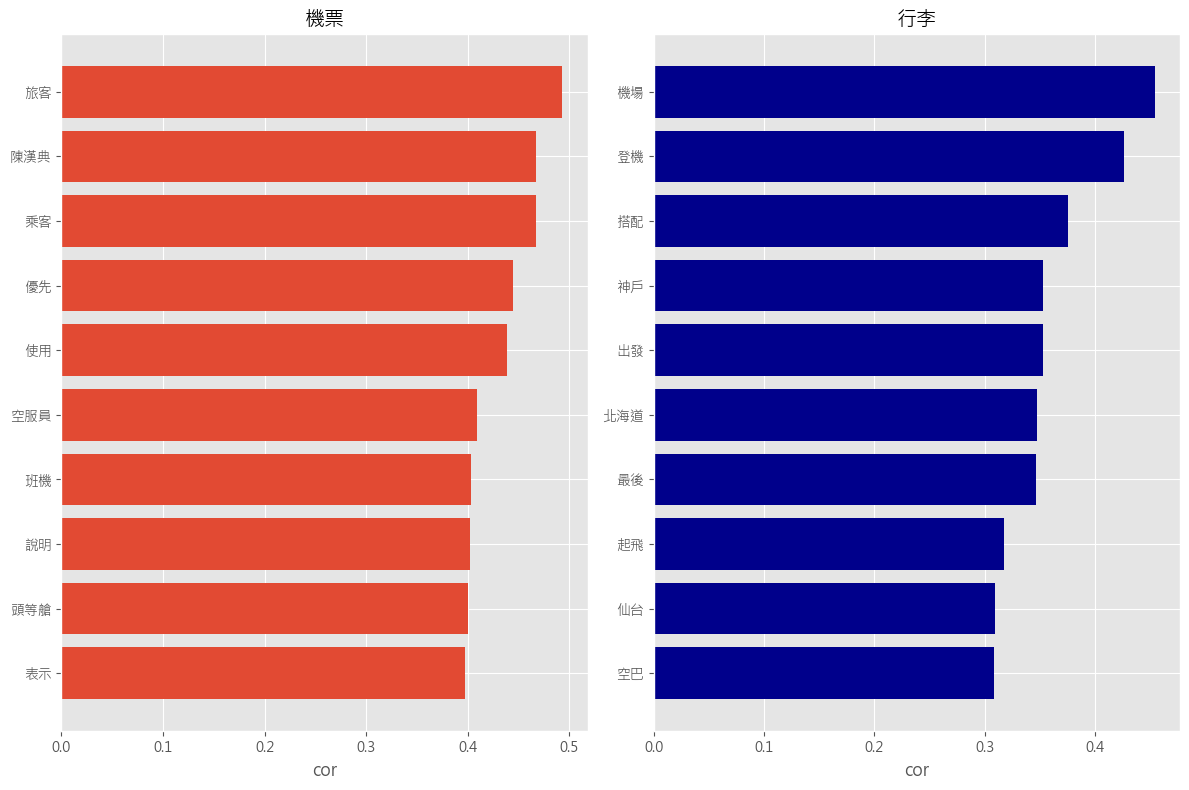

In [44]:
plt.figure(figsize=(12,8))   # 顯示圖框架大小 (寬,高)
plt.style.use("ggplot")     # 使用ggplot主題樣式

plt.subplot(121)
plt.title('機票')
plt.xlabel('cor')
plt.barh(ticket_sum['word2'],ticket_sum['cor'])
plt.gca().invert_yaxis()

plt.subplot(122)
plt.title('行李')
plt.xlabel('cor')
plt.barh(baggage_sum['word2'],baggage_sum['cor'],color="darkblue")
plt.gca().invert_yaxis()
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']

plt.tight_layout()
plt.show()

5.2 使用詞彙關係圖畫出以詞頻前60為節點且相關性高於0.3的組合

In [45]:
# 透過DTM找出詞頻前60高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})

most_freq_word = most_freq_df['word'].tolist()

In [46]:
# 保留存在詞頻前60高之詞彙的組合
filtered_df = word_cor_df[(word_cor_df['word1'].isin(most_freq_word)) & (word_cor_df['word2'].isin(most_freq_word))]

# 篩選出相關係數大於0.3的組合
filtered_df = filtered_df[filtered_df['cor'] > 0.3]
filtered_df.reset_index(inplace=True, drop=True)
filtered_df

,word1,word2,cor
0,台中,今年,0.318705
1,台北,今年,0.337721
2,員工,今年,0.382297
3,年終,今年,0.414942
4,張國煒,今年,0.348302
...,...,...,...
271,星宇,飛機,0.545718
272,獎金,飛機,0.300223
273,獲利,飛機,0.479631
274,航空,飛機,0.326411


In [47]:
# Create network plot
g = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 取得edge權重
weights = [w[2]['weight']*5 for w in  g.edges(data=True)]

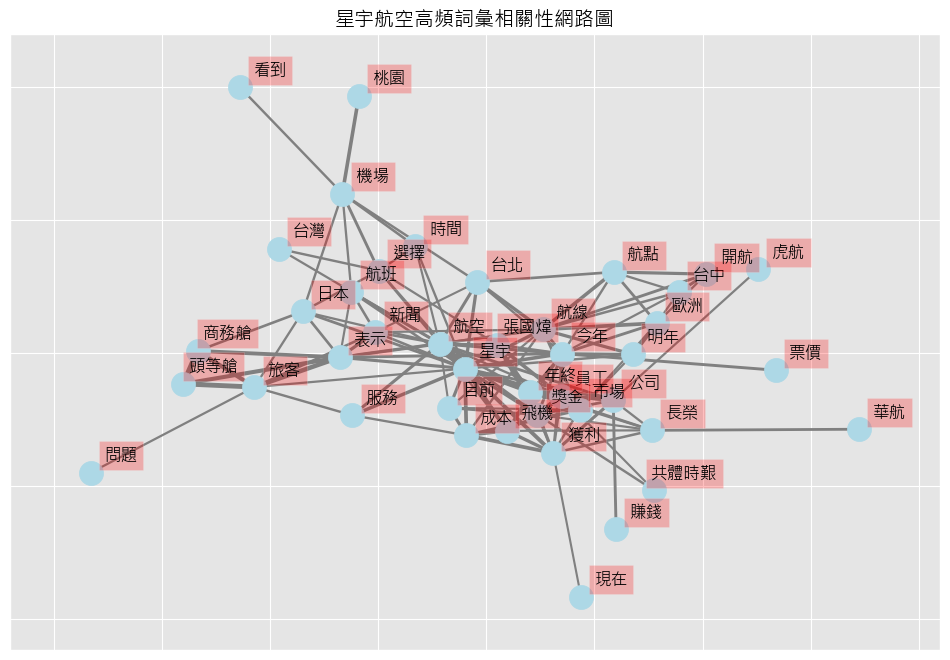

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(g, k=0.3)

# networks
nx.draw_networkx(g, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=12)

plt.title("星宇航空高頻詞彙相關性網路圖")
plt.show()

從圖中可以清楚看出具有高度相連關係的詞彙。

## 6. 計算文章相似度

以TF-IDF的結果當作文章的向量，計算 Cosine Similarity 找出相似的文章

In [49]:
data_cos = data_cor.copy()
data_cos.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡 台灣 星宇星 加坡 長榮 票價 星宇 便宜 明白 那麼多 選星宇 累計 里程 ...
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,這有 糾結 沒高卡 哩程 需求 便宜
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,星宇 看到 托運 一件 最近 注意到


In [50]:
transformer = TfidfTransformer()
print(transformer)
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())
TFIDF_df

TfidfTransformer()


,一下,一堆,一天,一年,一架,一次,一直,一間,一點,三家,...,飛航,飛行,餐點,首架,首爾,首航,香港,體驗,高雄,鳳凰城
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


計算文章間的cosine similarity

In [51]:
cosine_matrix = cosine_similarity(tfidf.toarray(), tfidf.toarray())

檢視與第一篇文章相似的文章

In [52]:
cos_df = pd.DataFrame(cosine_matrix[0], columns = ['cos_similarity'])
cos_df

,cos_similarity
0,1.000000
1,0.180238
2,0.059250
3,0.400748
4,0.214058
...,...
4078,0.000000
4079,0.000000
4080,0.000000
4081,0.000000


In [53]:
cos_df = cos_df.merge(data_cos, how = 'left', left_index=True, right_index=True)
cos_df.loc[:,["cos_similarity", "artTitle", "artUrl"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

,cos_similarity,artTitle,artUrl
0,1.000000,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...
3477,0.432071,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770952324.A.86...
1885,0.413368,[新聞] 星宇張國煒：今年14架新機加入 壓力大,https://www.ptt.cc/bbs/Aviation/M.1767674291.A...
3090,0.400748,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770962937.A.05...
2101,0.400748,[新聞] 星宇公布年終1個月、整體調薪3% 有員工抱,https://www.ptt.cc/bbs/Aviation/M.1767066330.A...
3797,0.400748,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3794,0.400748,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3783,0.400748,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
2466,0.400748,[新聞] 星宇航空將推宮古島航線 明年底增飛歐洲,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...
4017,0.400748,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...


檢視與第14篇文章相似的文章

In [54]:
cos_df_14 = pd.DataFrame(cosine_matrix[0], columns=['cos_similarity'])

cos_df_14 = cos_df_14.merge(data_cos, how = 'left', left_index=True, right_index=True)
cos_df_14.loc[:,["cos_similarity", "artTitle", "artUrl"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

,cos_similarity,artTitle,artUrl
0,1.000000,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...
3477,0.432071,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770952324.A.86...
1885,0.413368,[新聞] 星宇張國煒：今年14架新機加入 壓力大,https://www.ptt.cc/bbs/Aviation/M.1767674291.A...
3090,0.400748,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770962937.A.05...
2101,0.400748,[新聞] 星宇公布年終1個月、整體調薪3% 有員工抱,https://www.ptt.cc/bbs/Aviation/M.1767066330.A...
3797,0.400748,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3794,0.400748,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3783,0.400748,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
2466,0.400748,[新聞] 星宇航空將推宮古島航線 明年底增飛歐洲,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...
4017,0.400748,[新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767115196.A.D0...


## 7. 補充：建立Ngram預測模型

使用我們的抓取的 PTT 星宇航空資料集

In [55]:
data_ngram = data.copy()
sen_tokens = data_ngram.sentence.apply(getToken).tolist()

In [56]:
def ngram(documents, N=2):
    ngram_prediction = dict()
    total_grams = list()
    words = list()
    Word = namedtuple('Word', ['word', 'prob'])

    for doc in documents:
        # 加上開頭和結尾 tag
        split_words = ['<s>'] + list(doc) + ['</s>']
        # 計算分子
        [total_grams.append(tuple(split_words[i:i+N])) for i in range(len(split_words)-N+1)]
        # 計算分母
        [words.append(tuple(split_words[i:i+N-1])) for i in range(len(split_words)-N+2)]

    total_word_counter = Counter(total_grams)
    word_counter = Counter(words)

    for key in total_word_counter:
        word = ''.join(key[:N-1])
        if word not in ngram_prediction:
            ngram_prediction.update({word: set()})

        next_word_prob = total_word_counter[key]/word_counter[key[:N-1]] #P(B|A)
        w = Word(key[-1], '{:.3g}'.format(next_word_prob))
        ngram_prediction[word].add(w)

    return ngram_prediction

In [57]:
# Bigram預測模型為例
bi_prediction = ngram(sen_tokens, N=2)

預測下一個出現的詞

In [58]:
text = '星宇'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: 航空, probability: 0.258
next word: 員工, probability: 0.0339
next word: </s>, probability: 0.0276
next word: 飛機, probability: 0.0163
next word: 現在, probability: 0.0113


In [59]:
text = '張國煒'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: 吃定, probability: 0.058
next word: 經營, probability: 0.0435
next word: 老本, probability: 0.029
next word: 表示, probability: 0.029
next word: 豪氣, probability: 0.029
